In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import mannwhitneyu

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

base = '/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory'
conditions = ['wiii8', 'anosmic', '9047', '23129', '33300']
condition_colors = {
    'wiii8': '#385491',
    'anosmic': '#be0f0a',
    '9047': '#e7533a',
    '23129': '#fc8c59',
    '33300': '#fead61',
}

bouts = pd.concat(
    [pd.read_csv(f'{base}/{c}/interaction_type_bout.csv').assign(condition=c) for c in conditions],
    ignore_index=True,
)

distance = pd.concat(
    [pd.read_csv(f'{base}/{c}/distance_travelled.csv').assign(condition=c) for c in conditions],
    ignore_index=True,
)

In [ ]:
# Each larva is cut at the frame where it has itself travelled BUDGET mm, so every larva
# contributes exactly the same amount of travel regardless of how fast it moved.
BUDGET = 1000

cut = (
    distance[distance['distance_travelled'] >= BUDGET]
    .groupby(['condition', 'file', 'track'], as_index=False)['frame']
    .min()
    .rename(columns={'frame': 'cut_frame'})
)

# Larvae that never reach BUDGET are dropped - check how many.
print(pd.DataFrame({
    'kept': cut.groupby('condition').size(),
    'total': distance.groupby(['condition', 'file', 'track']).size().groupby('condition').size(),
}).assign(percent=lambda x: (x.kept / x.total * 100).round(0)).loc[conditions])

           kept  total  percent
condition                      
wiii8        50     50    100.0
anosmic      49     50     98.0
9047         50     50    100.0
23129        50     51     98.0
33300        45     50     90.0


In [18]:
# One row per larva per bout, so each bout counts for both animals involved.
long = pd.concat([
    bouts[['condition', 'file', 'track_1', 'start_frame', 'duration']].rename(columns={'track_1': 'track'}),
    bouts[['condition', 'file', 'track_2', 'start_frame', 'duration']].rename(columns={'track_2': 'track'}),
])

# Keep only bouts that started inside that larva's own first BUDGET mm.
kept = long.merge(cut, on=['condition', 'file', 'track'])
kept = kept[kept['start_frame'] <= kept['cut_frame']]

n_bouts = kept.groupby(['condition', 'file', 'track']).size().reset_index(name='n_bouts')

# Start from cut so larvae with no interactions stay in as zeros.
per_larva = cut.merge(n_bouts, on=['condition', 'file', 'track'], how='left')
per_larva['n_bouts'] = per_larva['n_bouts'].fillna(0)

print(per_larva.groupby('condition')['n_bouts'].agg(['size', 'mean', 'median']).round(1).loc[conditions])

           size  mean  median
condition                    
wiii8        50  13.4    13.0
anosmic      49   6.1     5.0
9047         50   8.9     8.0
23129        50   7.9     7.0
33300        45  10.4    10.0


      comparison    U        p significance
anosmic vs wiii8  7.5 0.001487           **
   9047 vs wiii8 23.5 0.049281            *
  23129 vs wiii8 15.5 0.010137            *
  33300 vs wiii8 32.0 0.185546           ns


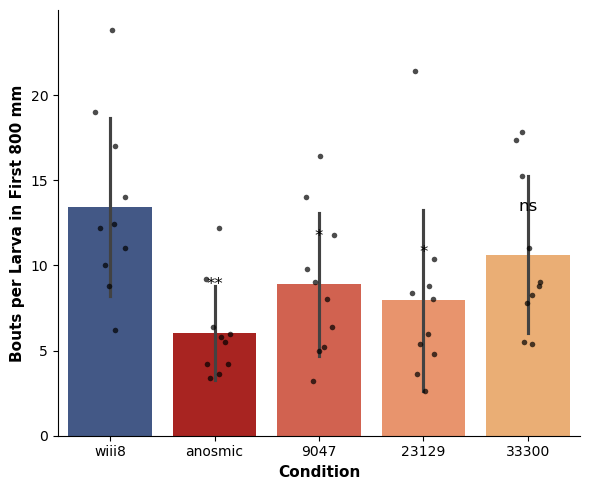

In [19]:
# Larvae in a dish share bouts with each other, so test at the recording level.
per_recording = per_larva.groupby(['condition', 'file'], as_index=False)['n_bouts'].mean()

control = per_recording.loc[per_recording['condition'] == 'wiii8', 'n_bouts']
stats_rows = []

for condition in conditions:
    if condition == 'wiii8':
        continue

    test_group = per_recording.loc[per_recording['condition'] == condition, 'n_bouts']
    u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{condition} vs wiii8',
        'U': u_stat,
        'p': p_value,
        'significance': significance,
    })

stats_table = pd.DataFrame(stats_rows)
print(stats_table.to_string(index=False))

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=per_recording,
    x='condition',
    y='n_bouts',
    order=conditions,
    hue='condition',
    hue_order=conditions,
    palette=condition_colors,
    errorbar='sd',
    legend=False,
)

sns.stripplot(
    data=per_recording,
    x='condition',
    y='n_bouts',
    order=conditions,
    color='black',
    size=4,
    jitter=0.15,
    alpha=0.7,
    ax=ax,
)

y_offset = per_recording['n_bouts'].max() * 0.1
for row in stats_rows:
    condition = row['comparison'].split(' vs ')[0]
    x = conditions.index(condition)
    y = per_recording.loc[per_recording['condition'] == condition, 'n_bouts'].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.ylim(0, None)
plt.ylabel(f'Bouts per Larva in First {BUDGET} mm', fontsize=11, fontweight='bold')
plt.xlabel('Condition', fontsize=11, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

In [20]:
# Check the result is not an artefact of the budget chosen above.
rows = []

for budget in [600, 800, 1000, 1200, 1500]:
    budget_cut = (
        distance[distance['distance_travelled'] >= budget]
        .groupby(['condition', 'file', 'track'], as_index=False)['frame']
        .min()
        .rename(columns={'frame': 'cut_frame'})
    )

    budget_kept = long.merge(budget_cut, on=['condition', 'file', 'track'])
    budget_kept = budget_kept[budget_kept['start_frame'] <= budget_kept['cut_frame']]

    budget_larva = budget_cut.merge(
        budget_kept.groupby(['condition', 'file', 'track']).size().reset_index(name='n_bouts'),
        on=['condition', 'file', 'track'],
        how='left',
    )
    budget_larva['n_bouts'] = budget_larva['n_bouts'].fillna(0)
    budget_larva['budget'] = budget
    rows.append(budget_larva)

sensitivity = pd.concat(rows, ignore_index=True)

print('mean bouts per larva')
print(sensitivity.pivot_table(index='budget', columns='condition', values='n_bouts', aggfunc='mean')[conditions].round(1))
print()
print('larvae reaching the budget')
print(sensitivity.pivot_table(index='budget', columns='condition', values='n_bouts', aggfunc='size')[conditions])

mean bouts per larva
condition  wiii8  anosmic  9047  23129  33300
budget                                       
600         10.4      5.2   7.3    5.7    9.0
800         13.4      6.1   8.9    7.9   10.4
1000        16.2      7.3  10.3    9.6   12.0
1200        19.6      8.4  12.2   11.1   12.9
1500        23.8     10.1  14.2   13.3   13.6

larvae reaching the budget
condition  wiii8  anosmic  9047  23129  33300
budget                                       
600           50       49    50     50     47
800           50       49    50     50     45
1000          50       49    50     49     40
1200          50       48    47     46     35
1500          48       44    46     45     27


In [ ]:
# Mean bout duration per recording, using the same first-BUDGET mm window.
duration = kept.groupby(['condition', 'file'], as_index=False)['duration'].mean()

control = duration.loc[duration['condition'] == 'wiii8', 'duration']
stats_rows = []

for condition in conditions:
    if condition == 'wiii8':
        continue

    test_group = duration.loc[duration['condition'] == condition, 'duration']
    u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{condition} vs wiii8',
        'U': u_stat,
        'p': p_value,
        'significance': significance,
    })

stats_table = pd.DataFrame(stats_rows)
print(stats_table.to_string(index=False))

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=duration,
    x='condition',
    y='duration',
    order=conditions,
    hue='condition',
    hue_order=conditions,
    palette=condition_colors,
    errorbar='sd',
    legend=False,
)

sns.stripplot(
    data=duration,
    x='condition',
    y='duration',
    order=conditions,
    color='black',
    size=4,
    jitter=0.15,
    alpha=0.7,
    ax=ax,
)

y_offset = duration['duration'].max() * 0.1
for row in stats_rows:
    condition = row['comparison'].split(' vs ')[0]
    x = conditions.index(condition)
    y = duration.loc[duration['condition'] == condition, 'duration'].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.ylim(0, None)
plt.ylabel(f'Mean Bout Duration in First {BUDGET} mm (s)', fontsize=11, fontweight='bold')
plt.xlabel('Condition', fontsize=11, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()